# Experiment 5: Improved Large Dataset Classification

Keep the TF-IDF setup from Experiment 4 and change only the classifier to LinearSVC.

## Hypothesis

LinearSVC should improve over Logistic Regression because max-margin learning is often strong on sparse text features.  
This should be especially useful for `type` and `tag_1`, where discriminative keywords and phrases are frequent.

## Pipeline

**load Experiment 4 splits -> TF-IDF + LinearSVC -> evaluation -> compare with Experiment 4/3**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

## 1. Paths

In [2]:
ROOT = Path.cwd().parents[2]
OUT_DIR = ROOT / 'results' / 'Experiment_4_5_LargeDataset'
EXP3 = ROOT / 'results' / 'Experiment_3_BERTMNLI'

tasks = ['priority', 'type', 'tag_1_top8']
SEED = 42

## 2. Improved Model

Same TF-IDF representation as Experiment 4; only the classifier changes.

In [3]:
# Same TF-IDF representation as Experiment 4; only the classifier changes.
def make_svc_model():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
            stop_words='english',
        )),
        ('clf', LinearSVC(
            C=0.5,
            class_weight='balanced',
            random_state=SEED,
            max_iter=5000,
        )),
    ])

def get_scores(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro-F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Weighted-F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

## 3. Training and Evaluation

In [4]:
rows = []

for task in tasks:
    train_df = pd.read_csv(OUT_DIR / f'Experiment_4_{task}_train.csv')
    val_df = pd.read_csv(OUT_DIR / f'Experiment_4_{task}_val.csv')
    test_df = pd.read_csv(OUT_DIR / f'Experiment_4_{task}_test.csv')

    model = make_svc_model()
    model.fit(train_df['text_cleaned'], train_df['label'])

    val_pred = model.predict(val_df['text_cleaned'])
    test_pred = model.predict(test_df['text_cleaned'])

    val_scores = get_scores(val_df['label'], val_pred)
    test_scores = get_scores(test_df['label'], test_pred)

    row = {'task': task, 'model': 'TF-IDF + LinearSVC'}
    row.update(test_scores)
    rows.append(row)

    pred_df = test_df.copy()
    pred_df['pred_label'] = test_pred
    pred_df.to_csv(OUT_DIR / f'Experiment_5_{task}_improved_predictions.csv', index=False, encoding='utf-8')

    print(f'\n{task}')
    print(f'Validation Macro-F1: {val_scores["Macro-F1"]:.4f}')
    print(classification_report(test_df['label'], test_pred, zero_division=0))

svc_summary = pd.DataFrame(rows)
svc_summary.to_csv(OUT_DIR / 'Experiment_5_large_svc_summary.csv', index=False)
svc_summary


priority
Validation Macro-F1: 0.7177
              precision    recall  f1-score   support

        high       0.74      0.75      0.75      2182
         low       0.72      0.65      0.68      1155
      medium       0.72      0.75      0.73      2312

    accuracy                           0.73      5649
   macro avg       0.73      0.72      0.72      5649
weighted avg       0.73      0.73      0.73      5649




type
Validation Macro-F1: 0.8904
              precision    recall  f1-score   support

      Change       0.99      0.95      0.97       598
    Incident       0.86      0.89      0.87      2241
     Problem       0.77      0.72      0.74      1177
     Request       0.98      0.99      0.99      1633

    accuracy                           0.89      5649
   macro avg       0.90      0.89      0.89      5649
weighted avg       0.89      0.89      0.89      5649




tag_1_top8
Validation Macro-F1: 0.9181
              precision    recall  f1-score   support

     Billing       0.99      0.98      0.99       314
         Bug       0.91      0.90      0.91       813
     Feature       0.84      0.86      0.85       538
    Feedback       0.89      0.91      0.90       657
      Outage       0.92      0.93      0.93       197
 Performance       0.88      0.86      0.87       463
    Security       0.95      0.98      0.97      1073
   Technical       0.92      0.85      0.88       611

    accuracy                           0.91      4666
   macro avg       0.91      0.91      0.91      4666
weighted avg       0.91      0.91      0.91      4666



,task,model,Accuracy,Macro-F1,Weighted-F1
0,priority,TF-IDF + LinearSVC,0.727739,0.719953,0.727226
1,type,TF-IDF + LinearSVC,0.890069,0.892710,0.889032
2,tag_1_top8,TF-IDF + LinearSVC,0.912130,0.910717,0.911893


## 4. Experiment 4 vs Experiment 5

In [5]:
baseline_summary = pd.read_csv(OUT_DIR / 'Experiment_4_large_baseline_summary.csv')
comp = pd.concat([baseline_summary, svc_summary], ignore_index=True)
comp.to_csv(OUT_DIR / 'Experiment_5_large_baseline_vs_improved.csv', index=False)
comp

,task,model,Accuracy,Macro-F1,Weighted-F1
0,priority,TF-IDF + Logistic Regression,0.700478,0.692097,0.700871
1,type,TF-IDF + Logistic Regression,0.878563,0.885003,0.879330
2,tag_1_top8,TF-IDF + Logistic Regression,0.899700,0.898191,0.899660
3,priority,TF-IDF + LinearSVC,0.727739,0.719953,0.727226
4,type,TF-IDF + LinearSVC,0.890069,0.892710,0.889032
5,tag_1_top8,TF-IDF + LinearSVC,0.912130,0.910717,0.911893


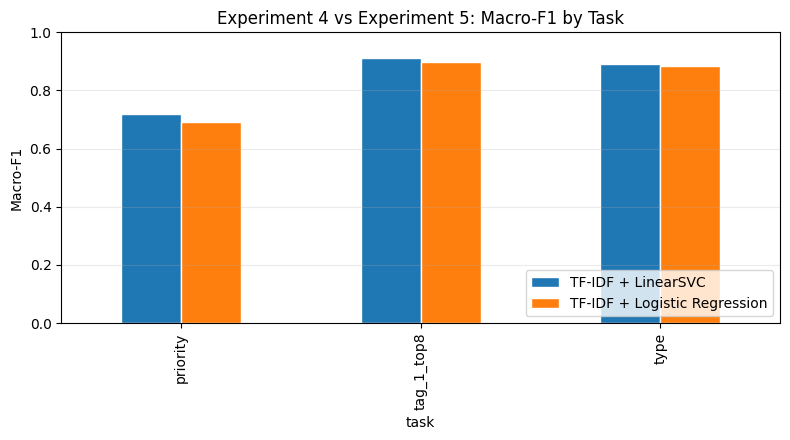

In [6]:
metric = 'Macro-F1'
pivot = comp.pivot(index='task', columns='model', values=metric)

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_ylim(0, 1.0)
ax.set_ylabel(metric)
ax.set_title('Experiment 4 vs Experiment 5: Macro-F1 by Task')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / 'Experiment_5_large_macro_f1_comp.png', dpi=150)
plt.show()

## 5. Comparison with Experiment 3b

Direct Experiment 3 comparison starts with `priority`, since Experiment 3b uses the same three-class target on the same large dataset.  
Tag comparison is handled separately with the Experiment 3a Top-2 metrics.

In [7]:
# Priority is directly comparable with Experiment 3b: same 3 labels.
# Recompute Experiment 3 zero-shot priority metrics from its saved predictions.
ZS_PRIORITY_PATH = EXP3 / 'Experiment_3_zeroshot_large_predictions.csv'
if ZS_PRIORITY_PATH.exists():
    zs = pd.read_csv(ZS_PRIORITY_PATH)
    exp3_zs = {
        'model': 'Exp3 Zero-shot BART-MNLI',
        'Accuracy': accuracy_score(zs['true'], zs['pred']),
        'Macro-F1': f1_score(zs['true'], zs['pred'], average='macro', zero_division=0),
        'Weighted-F1': f1_score(zs['true'], zs['pred'], average='weighted', zero_division=0),
    }
else:
    exp3_zs = {'model': 'Exp3 Zero-shot BART-MNLI', 'Accuracy': 0.388, 'Macro-F1': 0.229, 'Weighted-F1': 0.254}

# Experiment 3b fine-tuned values are printed in the notebook output.
exp3_ft = {
    'model': 'Exp3 Fine-tuned RoBERTa',
    'Accuracy': 0.6019,
    'Macro-F1': 0.5943,
    'Weighted-F1': 0.5997,
}

priority_baseline = baseline_summary[baseline_summary['task'] == 'priority'].iloc[0]
priority_improved = svc_summary[svc_summary['task'] == 'priority'].iloc[0]

pri_comp = pd.DataFrame([
    exp3_zs,
    exp3_ft,
    {
        'model': 'Exp4 TF-IDF + Logistic Regression',
        'Accuracy': priority_baseline['Accuracy'],
        'Macro-F1': priority_baseline['Macro-F1'],
        'Weighted-F1': priority_baseline['Weighted-F1'],
    },
    {
        'model': 'Exp5 TF-IDF + LinearSVC',
        'Accuracy': priority_improved['Accuracy'],
        'Macro-F1': priority_improved['Macro-F1'],
        'Weighted-F1': priority_improved['Weighted-F1'],
    },
])
pri_comp.to_csv(OUT_DIR / 'Experiment_5_priority_vs_experiment3.csv', index=False)
pri_comp

,model,Accuracy,Macro-F1,Weighted-F1
0,Exp3 Zero-shot BART-MNLI,0.388096,0.229148,0.254188
1,Exp3 Fine-tuned RoBERTa,0.601900,0.594300,0.599700
2,Exp4 TF-IDF + Logistic Regression,0.700478,0.692097,0.700871
3,Exp5 TF-IDF + LinearSVC,0.727739,0.719953,0.727226


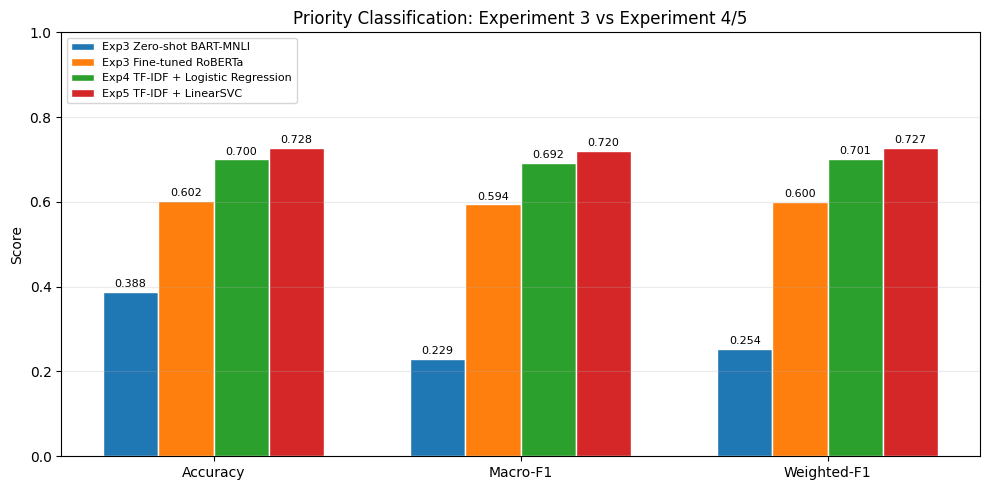

In [8]:
metrics = ['Accuracy', 'Macro-F1', 'Weighted-F1']
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(pri_comp.iterrows()):
    offset = (i - (len(pri_comp) - 1) / 2) * width
    values = [row[m] for m in metrics]
    bars = ax.bar(x + offset, values, width, label=row['model'], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Priority Classification: Experiment 3 vs Experiment 4/5')
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / 'Experiment_5_priority_vs_experiment3.png', dpi=150)
plt.show()

## 6. Tag Comparison with Experiment 3a

Experiment 3a is a Top-2 multi-label tag task, so `tag_1_top8` is not the fair comparison point.  
Reuse the Experiment 3a prediction file and 6/2/2 split, then train TF-IDF baselines for both `tag_1` and `tag_2`.

Use the same metrics as Experiment 3a: `Exact@2`, `Hit@2`, `Jaccard`, `Micro-F1`, and `Macro-F1`.

In [9]:
# Reuse Experiment 3a's Top-2 setup for a fair tag comparison.
TAG_PRED_PATH = EXP3 / 'Experiment_3a_large_tfidf_mnli_predictions.csv'
EXP3_TAG_SUMMARY = EXP3 / 'Experiment_3a_finetune_vs_zeroshot_summary.csv'

tag_df = pd.read_csv(TAG_PRED_PATH).copy()
tag_df = tag_df.dropna(subset=['text', 'true_tag_1', 'true_tag_2']).reset_index(drop=True)

# Match the Experiment 3a fine-tuning split: random permutation, 6/2/2.
rng = np.random.RandomState(42)
perm = rng.permutation(len(tag_df))
n = len(tag_df)
n_train = int(0.6 * n)
n_val = int(0.2 * n)

tag_train = tag_df.iloc[perm[:n_train]].reset_index(drop=True)
tag_val = tag_df.iloc[perm[n_train:n_train + n_val]].reset_index(drop=True)
tag_test = tag_df.iloc[perm[n_train + n_val:]].reset_index(drop=True)

TAGS = sorted(set(tag_df['true_tag_1']).union(set(tag_df['true_tag_2'])))
tag2id = {tag: i for i, tag in enumerate(TAGS)}
id2tag = {i: tag for tag, i in tag2id.items()}

print(f'Tag comp rows: train={len(tag_train)} val={len(tag_val)} test={len(tag_test)} labels={len(TAGS)}')

Tag comp rows: train=2400 val=800 test=800 labels=72


In [10]:
def make_y_tag(frame):
    y = np.zeros((len(frame), len(TAGS)), dtype=int)
    for i, (tag1, tag2) in enumerate(zip(frame['true_tag_1'], frame['true_tag_2'])):
        y[i, tag2id[tag1]] = 1
        y[i, tag2id[tag2]] = 1
    return y

def get_top2(scores):
    return np.argsort(-scores, axis=1)[:, :2]

def score_top2(y_true_bin, top2_idx):
    y_pred_bin = np.zeros_like(y_true_bin)
    for i in range(len(top2_idx)):
        y_pred_bin[i, top2_idx[i, 0]] = 1
        y_pred_bin[i, top2_idx[i, 1]] = 1

    true_sets = [set(np.where(y_true_bin[i] > 0)[0].tolist()) for i in range(y_true_bin.shape[0])]
    pred_sets = [set(top2_idx[i].tolist()) for i in range(top2_idx.shape[0])]

    exact = np.mean([t == p for t, p in zip(true_sets, pred_sets)])
    hit2 = np.mean([len(t & p) > 0 for t, p in zip(true_sets, pred_sets)])
    jaccard = np.mean([len(t & p) / len(t | p) if len(t | p) > 0 else 0.0 for t, p in zip(true_sets, pred_sets)])
    micro = f1_score(y_true_bin, y_pred_bin, average='micro', zero_division=0)
    macro = f1_score(y_true_bin, y_pred_bin, average='macro', zero_division=0)
    return exact, hit2, jaccard, micro, macro

def train_tag_models(train_frame, model_name):
    vectorizer = TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        stop_words='english',
    )
    x_train = vectorizer.fit_transform(train_frame['text'])
    y_train = make_y_tag(train_frame)

    models = []
    for j in range(len(TAGS)):
        y_col = y_train[:, j]
        # Some rare tags are absent from the train split; keep them out with a low score.
        if y_col.sum() == 0:
            models.append(('constant', -1e6))
            continue
        if y_col.sum() == len(y_col):
            models.append(('constant', 1e6))
            continue

        if model_name == 'logreg':
            clf = LogisticRegression(max_iter=2000, class_weight='balanced', C=2.0, random_state=SEED)
        elif model_name == 'linearsvc':
            clf = LinearSVC(C=0.5, class_weight='balanced', random_state=SEED, max_iter=5000)
        else:
            raise ValueError(model_name)
        clf.fit(x_train, y_col)
        models.append(clf)
    return vectorizer, models

def get_tag_scores(vectorizer, models, frame):
    x = vectorizer.transform(frame['text'])
    cols = []
    for clf in models:
        if isinstance(clf, tuple) and clf[0] == 'constant':
            cols.append(np.full(x.shape[0], clf[1], dtype=float))
        elif hasattr(clf, 'decision_function'):
            cols.append(clf.decision_function(x))
        else:
            cols.append(clf.predict_proba(x)[:, 1])
    return np.vstack(cols).T

In [11]:
y_tag_test = make_y_tag(tag_test)
tag_rows = []

for model_name, display_name in [
    ('logreg', 'Exp4 TF-IDF + Logistic Regression'),
    ('linearsvc', 'Exp5 TF-IDF + LinearSVC'),
]:
    vectorizer, tag_models = train_tag_models(tag_train, model_name)
    scores = get_tag_scores(vectorizer, tag_models, tag_test)
    top2 = get_top2(scores)
    exact, hit2, jac, micro, macro = score_top2(y_tag_test, top2)

    tag_rows.append({
        'model': display_name,
        'Exact@2': exact,
        'Hit@2': hit2,
        'Jaccard': jac,
        'Micro-F1': micro,
        'Macro-F1': macro,
    })

    pred_tag_out = tag_test[['text', 'true_tag_1', 'true_tag_2']].copy()
    pred_tag_out['pred_tag_1'] = [id2tag[i] for i in top2[:, 0]]
    pred_tag_out['pred_tag_2'] = [id2tag[i] for i in top2[:, 1]]
    pred_tag_out.to_csv(OUT_DIR / f'Experiment_5_tag_multilabel_{model_name}_predictions.csv', index=False, encoding='utf-8')

exp3_tag_summary = pd.read_csv(EXP3_TAG_SUMMARY)
exp3_tag_summary = exp3_tag_summary[['model', 'Exact@2', 'Hit@2', 'Jaccard', 'Micro-F1', 'Macro-F1']]

tag_comp = pd.concat([exp3_tag_summary, pd.DataFrame(tag_rows)], ignore_index=True)
tag_comp.to_csv(OUT_DIR / 'Experiment_5_tag_vs_experiment3a.csv', index=False)
tag_comp

,model,Exact@2,Hit@2,Jaccard,Micro-F1,Macro-F1
0,Zero-shot BART-MNLI,0.02500,0.40625,0.152083,0.215625,0.196646
1,Fine-tuned RoBERTa + TF-IDF Top20 mask,0.40625,0.91000,0.574167,0.658125,0.219501
2,Exp4 TF-IDF + Logistic Regression,0.46875,0.93250,0.623333,0.700625,0.240587
3,Exp5 TF-IDF + LinearSVC,0.48000,0.93000,0.630000,0.705000,0.230309


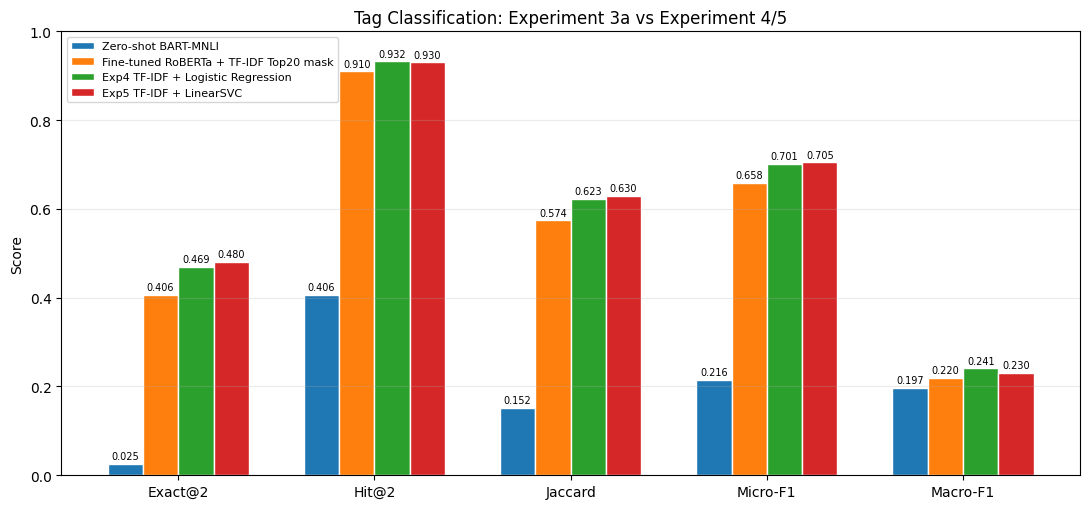

In [12]:
metrics = ['Exact@2', 'Hit@2', 'Jaccard', 'Micro-F1', 'Macro-F1']
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5.2))
for i, (_, row) in enumerate(tag_comp.iterrows()):
    offset = (i - (len(tag_comp) - 1) / 2) * width
    values = [row[m] for m in metrics]
    bars = ax.bar(x + offset, values, width, label=row['model'], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Tag Classification: Experiment 3a vs Experiment 4/5')
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / 'Experiment_5_tag_vs_experiment3a.png', dpi=150)
plt.show()

## 7. Confusion Matrices

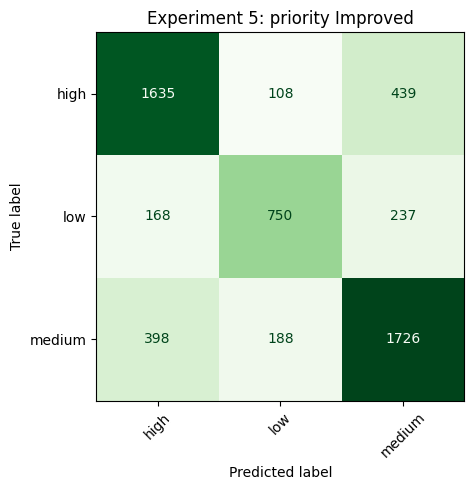

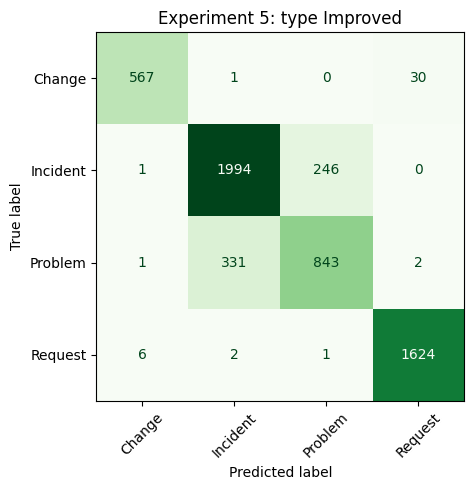

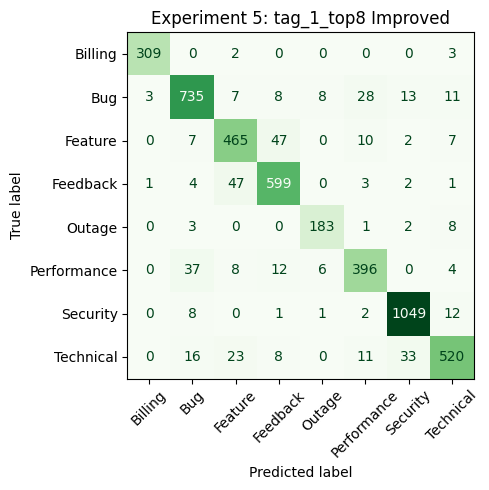

In [13]:
for task in tasks:
    pred_df = pd.read_csv(OUT_DIR / f'Experiment_5_{task}_improved_predictions.csv')
    labels = sorted(pred_df['label'].unique())

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        pred_df['label'],
        pred_df['pred_label'],
        labels=labels,
        cmap='Greens',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f'Experiment 5: {task} Improved')
    ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'Experiment_5_{task}_improved_confusion.png', dpi=150)
    plt.show()

## Conclusion

LinearSVC improves the Logistic Regression baseline across the large-dataset classification tasks.  
For priority, it also exceeds the saved Experiment 3 zero-shot and fine-tuned RoBERTa results under the same metric style.